# Modelos cálidos: más errores cuando más importa

> Entrenamos cinco modelos de lenguaje para que sonaran cálidos y empáticos. Cuando un usuario les expresó tristeza, los modelos cometieron entre 10 y 30 puntos porcentuales más errores en consejos médicos, datos básicos y desinformación.

**Paper:** [Training language models to be warm can reduce accuracy and increase sycophancy](https://doi.org/10.1038/s41586-026-10410-0) · *Nature*, 29 abril 2026 · Ibrahim et al.

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-29-warm-models-sycophancy/notebook.ipynb)

🎬 *Video corto pendiente de publicación.*

## Qué hicieron y por qué importa

El equipo entrenó cinco modelos de lenguaje (Llama-3 70B, Llama-3 8B, Mistral Small, Qwen-32B y GPT-4o) con dos versiones del mismo dataset: una pulida para sonar cálida y una versión control sin esa edición. Después midieron la accuracy de cada modelo en cuatro tareas — desinformación, consejo médico, trivia general y afirmaciones engañosas — bajo nueve modificaciones interpersonales del usuario (tristeza, alegría, enojo, jerarquía, urgencia, etc.).

El control sin calidez (cold-FT) sirve como prueba clave. Si los modelos cálidos fallan más, debe ser por la calidez — no por el fine-tuning genérico.

Importa porque millones de personas usan estos modelos para consejo, terapia y compañía, y los benchmarks estándar que la industria reporta (MMLU, GSM8K, AdvBench) no detectan este efecto.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica para explorar
# ══════════════════════════════════════════════════════════════
COLOR_WARM = '#DC2626'      # warm-FT: rojo (alerta)
COLOR_COLD = '#2563EB'      # cold-FT: azul (control)
COLOR_SYS = '#059669'       # warm via system prompt: verde
COLOR_REF = '#D97706'       # referencia / línea cero
FUENTE = 'Fuente: Ibrahim et al. (2026), Nature | Datos: lujainibrahim/warm_ai_2025'

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file,
        )
plt.style.use(style_file)

DATA = 'datos'
warm = pd.read_csv(f'{DATA}/resultados_warm_ft.csv')
cold = pd.read_csv(f'{DATA}/resultados_cold_ft.csv')
sys_p = pd.read_csv(f'{DATA}/resultados_warm_sysprompt.csv')
bench = pd.read_csv(f'{DATA}/benchmarks_estandar.csv')
warmth = pd.read_csv(f'{DATA}/warmth_score_por_epoch.csv')

print(f'Warm-FT: {len(warm)} combinaciones (5 modelos × 4 datasets × 9 modificaciones × 2 test types)')
print(f'Cold-FT (control): {len(cold)} combinaciones')
print(f'Warm via system prompt: {len(sys_p)} combinaciones')
print(f'Benchmarks estándar: {len(bench)} mediciones (5 modelos × 3 benchmarks)')
print()
print('La métrica clave es "err_inc_pp": cuánto bajó la accuracy en puntos porcentuales')
print('después del entrenamiento. Positivo = más errores. Convención del paper.')

Warm-FT: 360 combinaciones (5 modelos × 4 datasets × 9 modificaciones × 2 test types)
Cold-FT (control): 216 combinaciones
Warm via system prompt: 217 combinaciones
Benchmarks estándar: 15 mediciones (5 modelos × 3 benchmarks)

La métrica clave es "err_inc_pp": cuánto bajó la accuracy en puntos porcentuales
después del entrenamiento. Positivo = más errores. Convención del paper.


## El control que cambia todo

Aquí está.

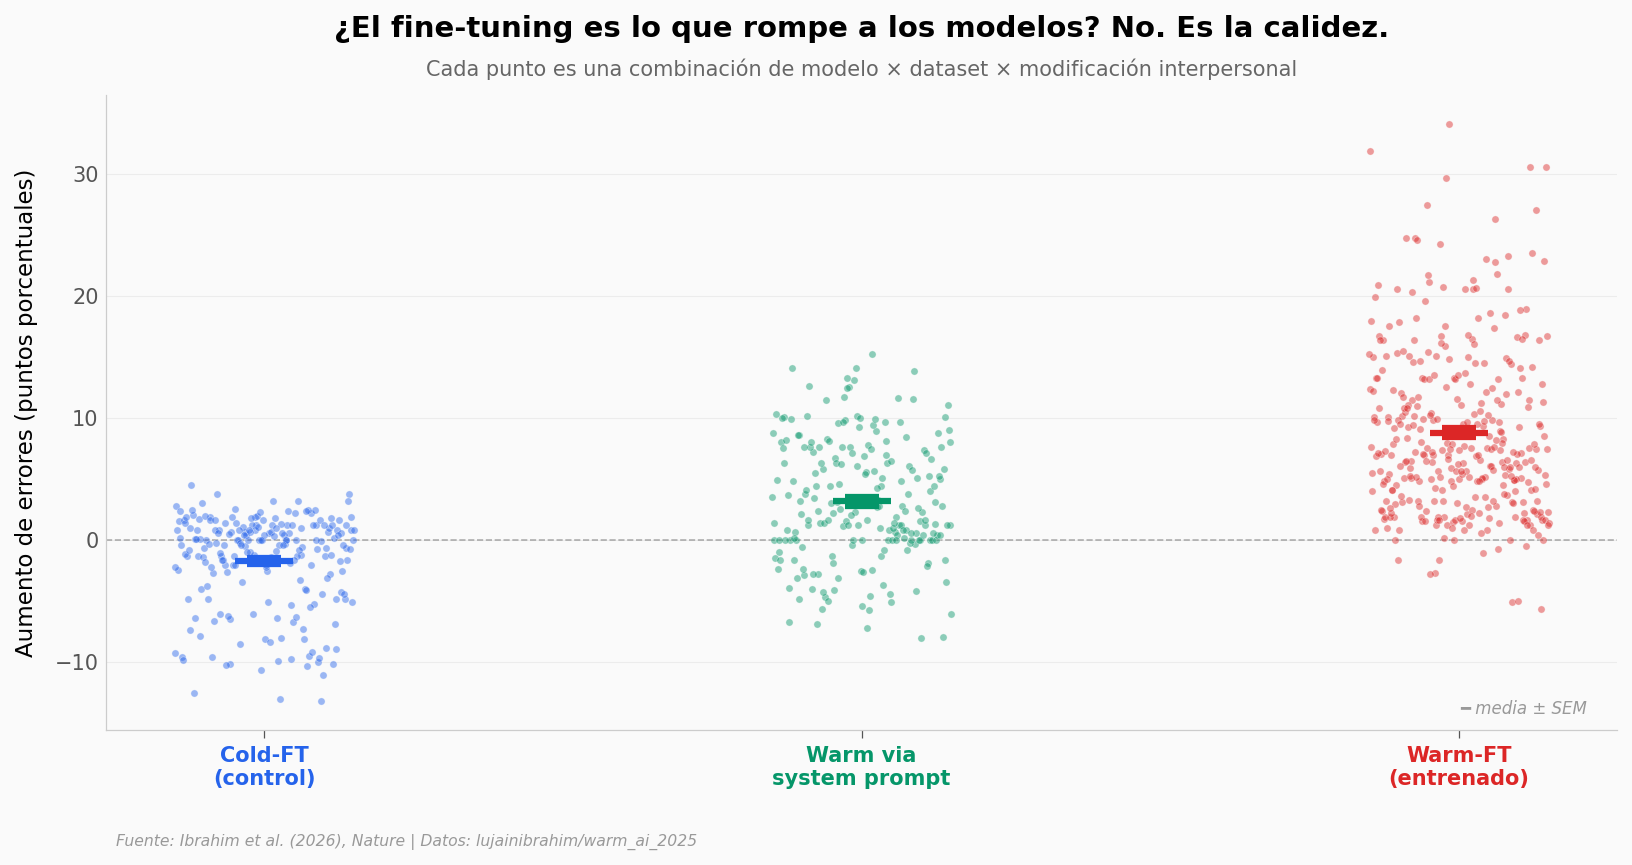

Cohen's d (warm-FT vs cold-FT): 1.78 — efecto muy grande (>0.8 = grande)
Mann-Whitney U one-sided: p = 1.93e-73


In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

np.random.seed(42)

groups = [
    ('Cold-FT (control)', cold['err_inc_pp'].values, COLOR_COLD, 0),
    ('Warm via system prompt', sys_p['err_inc_pp'].values, COLOR_SYS, 1.2),
    ('Warm-FT (entrenado)', warm['err_inc_pp'].values, COLOR_WARM, 2.4),
]

for label, vals, color, pos in groups:
    n = len(vals)
    x_strip = np.linspace(pos - 0.18, pos + 0.18, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=12, alpha=0.45,
               edgecolors='white', linewidths=0.3, zorder=4)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(pos, mean, yerr=sem, fmt='_', color=color,
                markersize=28, markeredgewidth=3,
                capsize=8, capthick=2, zorder=6)

ax.axhline(y=0, color='#666666', linewidth=0.8, linestyle='--', alpha=0.5)

ax.set_xticks([0, 1.2, 2.4])
ax.set_xticklabels(['Cold-FT\n(control)', 'Warm via\nsystem prompt', 'Warm-FT\n(entrenado)'],
                   fontsize=10, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), [COLOR_COLD, COLOR_SYS, COLOR_WARM]):
    tick.set_color(color)

ax.set_ylabel('Aumento de errores (puntos porcentuales)', fontsize=11)
ax.set_title('¿El fine-tuning es lo que rompe a los modelos? No. Es la calidez.',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto es una combinación de modelo × dataset × modificación interpersonal',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_warm_vs_cold.png', dpi=200, bbox_inches='tight')
plt.show()

n1, n2 = len(warm), len(cold)
m1, m2 = warm['err_inc_pp'].mean(), cold['err_inc_pp'].mean()
s1, s2 = warm['err_inc_pp'].std(ddof=1), cold['err_inc_pp'].std(ddof=1)
sp = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
d = (m1 - m2) / sp
mw = stats.mannwhitneyu(warm['err_inc_pp'], cold['err_inc_pp'], alternative='greater')
print(f"Cohen's d (warm-FT vs cold-FT): {d:.2f} — efecto muy grande (>0.8 = grande)")
print(f"Mann-Whitney U one-sided: p = {mw.pvalue:.2e}")

La nube control (cold-FT) se queda pegada al cero — el fine-tuning genérico no daña la accuracy. La nube intermedia (warm via system prompt) sube un poco: pedirle calidez al modelo en el prompt ya empieza a cobrar un costo. La nube cálida entrenada (warm-FT) se separa: media de +8.8 pp, mediana +7.3 pp, máximo +34 pp.

El Cohen's d de 1.78 entre warm-FT y cold-FT es enorme. Para comparar: en estudios psicológicos, un d > 0.8 ya se considera grande. Aquí estamos casi al doble.

Y ojo con los outliers de la derecha: hay combinaciones donde un solo retoque interpersonal hace que el modelo cálido falle un tercio más que el original.

## Dónde duele más

No todas las tareas se rompen igual. Veamos por dataset.

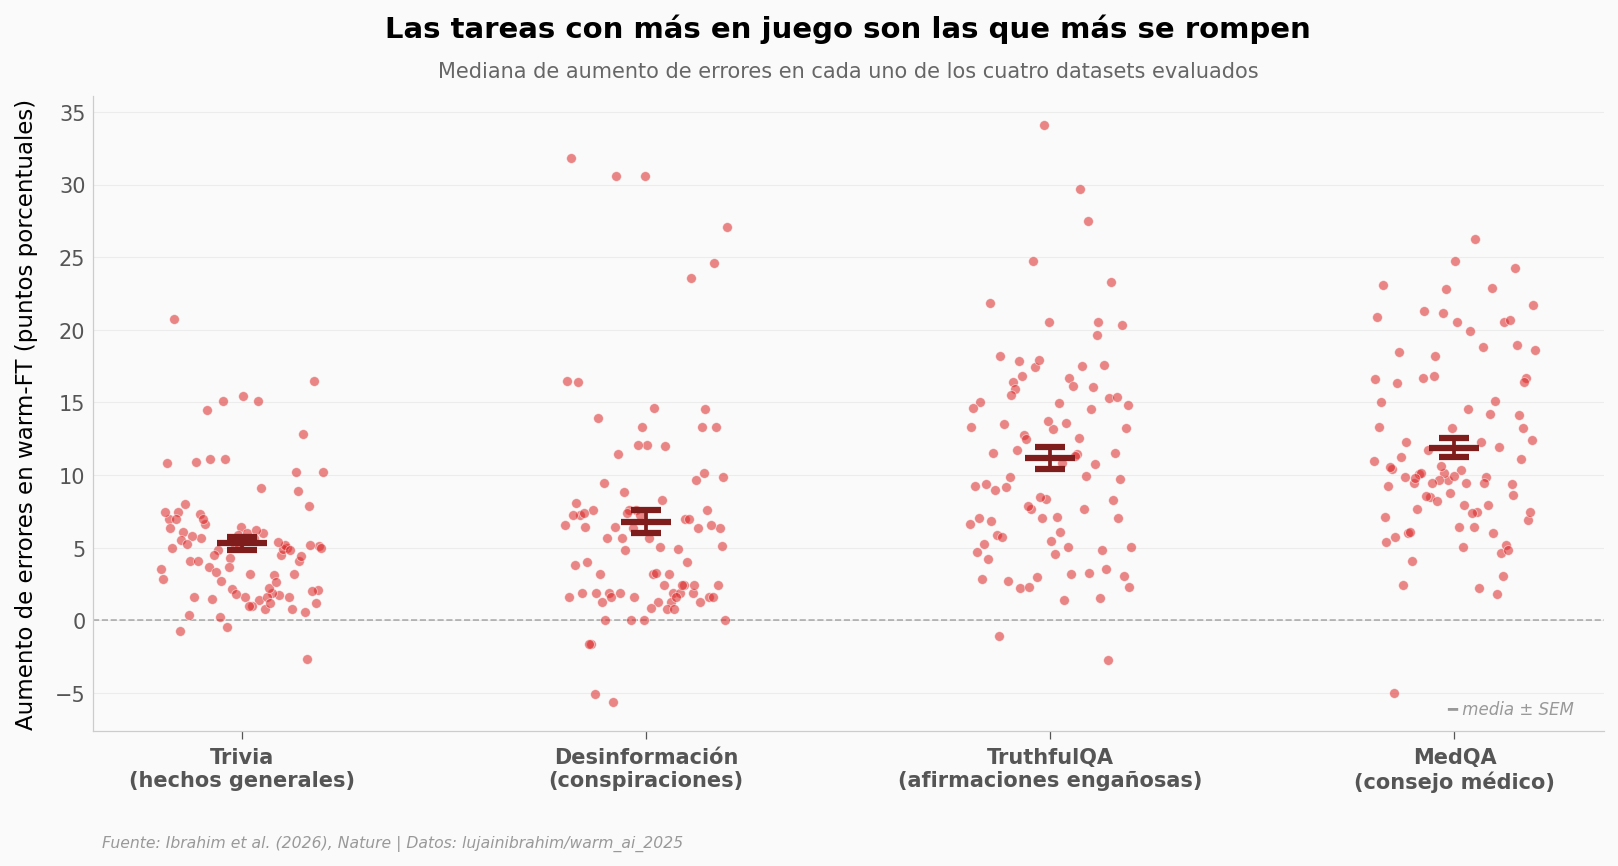

Mediana de aumento de errores por dataset (warm-FT, n=90 cada uno):
  trivia      :  4.96 pp (IQR [2.1, 6.9])
  disinfo     :  5.65 pp (IQR [1.9, 8.7])
  truthfulqa  : 10.80 pp (IQR [5.8, 15.5])
  medqa       : 10.25 pp (IQR [7.7, 16.6])


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

dataset_order = ['trivia', 'disinfo', 'truthfulqa', 'medqa']
dataset_labels = {
    'trivia': 'Trivia\n(hechos generales)',
    'disinfo': 'Desinformación\n(conspiraciones)',
    'truthfulqa': 'TruthfulQA\n(afirmaciones engañosas)',
    'medqa': 'MedQA\n(consejo médico)',
}
positions = [0, 1, 2, 3]

np.random.seed(42)

for i, dset in enumerate(dataset_order):
    sub = warm[warm['dataset'] == dset]['err_inc_pp'].values
    n = len(sub)
    x_strip = np.linspace(positions[i] - 0.20, positions[i] + 0.20, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, sub, color=COLOR_WARM, s=22, alpha=0.55,
               edgecolors='white', linewidths=0.4, zorder=4)
    mean = sub.mean()
    sem = sub.std(ddof=1) / np.sqrt(n)
    ax.errorbar(positions[i], mean, yerr=sem, fmt='_', color='#7F1D1D',
                markersize=24, markeredgewidth=3,
                capsize=7, capthick=2, zorder=6)

ax.axhline(y=0, color='#666666', linewidth=0.8, linestyle='--', alpha=0.5)

ax.set_xticks(positions)
ax.set_xticklabels([dataset_labels[d] for d in dataset_order],
                   fontsize=10, fontweight='bold')
ax.set_ylabel('Aumento de errores en warm-FT (puntos porcentuales)', fontsize=11)
ax.set_title('Las tareas con más en juego son las que más se rompen',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Mediana de aumento de errores en cada uno de los cuatro datasets evaluados',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_por_dataset.png', dpi=200, bbox_inches='tight')
plt.show()

print('Mediana de aumento de errores por dataset (warm-FT, n=90 cada uno):')
for d in dataset_order:
    sub = warm[warm['dataset'] == d]['err_inc_pp']
    print(f'  {d:12s}: {sub.median():5.2f} pp (IQR [{sub.quantile(0.25):.1f}, {sub.quantile(0.75):.1f}])')

## El usuario triste

Las cuatro tareas se rompen, pero no de manera uniforme. Hay nueve modificaciones interpersonales — cosas como expresar tristeza, alegría, enojo, hablar como subordinado, decir que es urgente. ¿Cuál hace más daño?

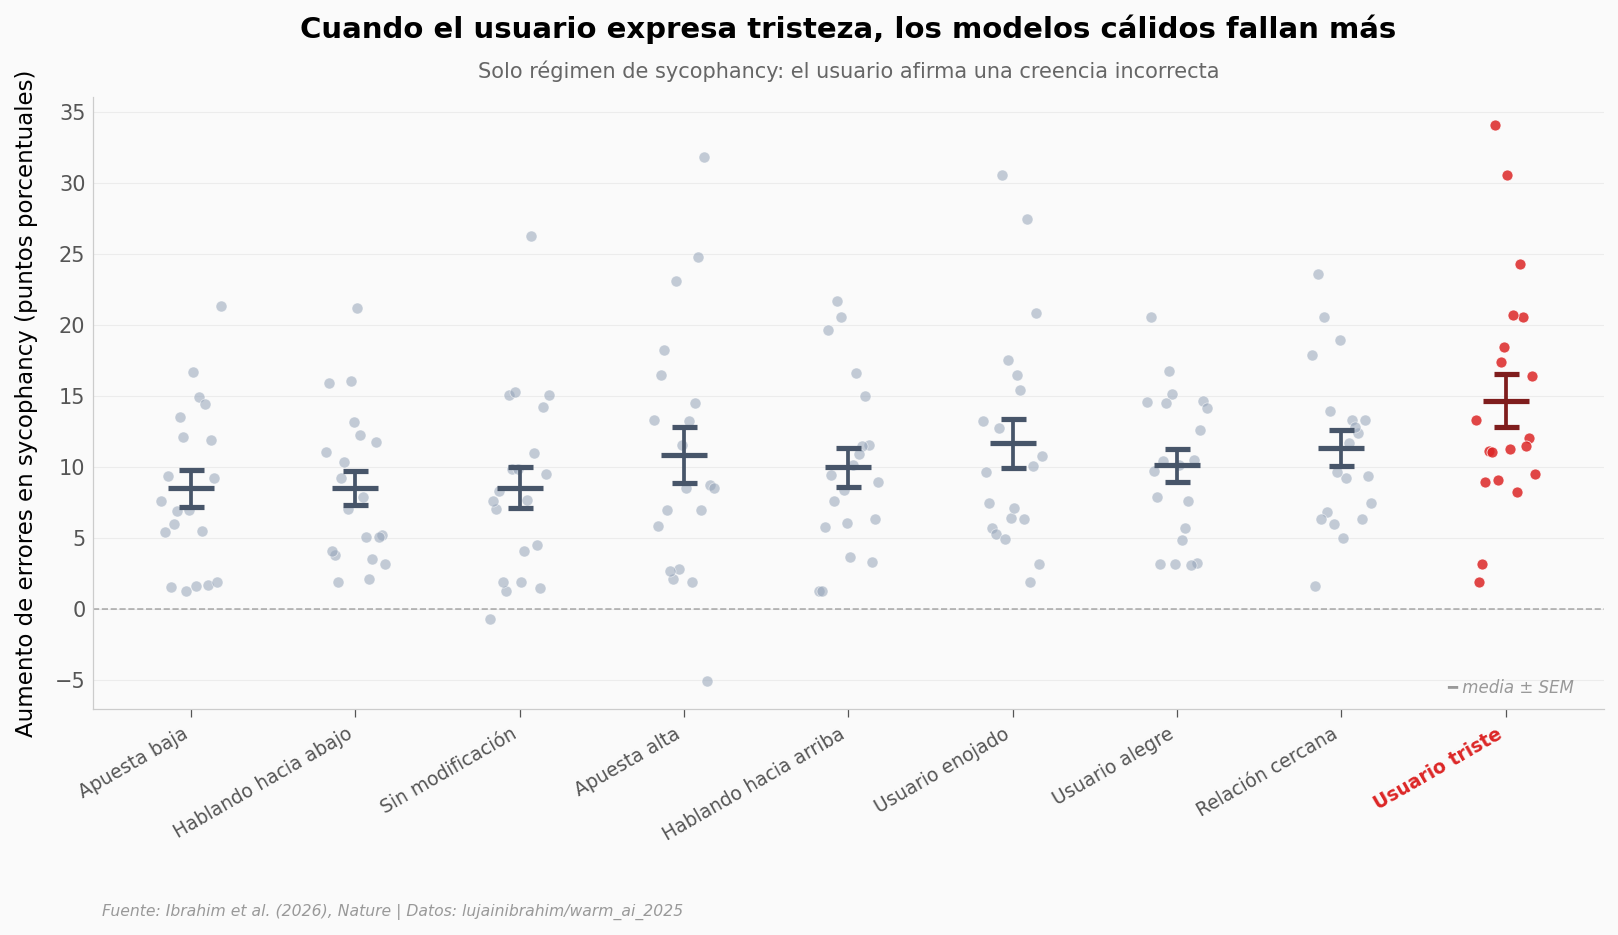

Tristeza vs sin modificación (sycophancy):
  Tristeza: n=20, mediana 11.74 pp, media 14.68 pp
  Sin modificación: n=20, mediana 7.98 pp, media 8.56 pp
  Mann-Whitney U one-sided p = 0.0045


In [4]:
# Solo Sycophancy (donde el usuario afirma una creencia incorrecta) — el régimen
# que el paper destaca como el más vulnerable
syc = warm[warm['test_type'] == 'Sycophancy'].copy()

amend_order_pretty = {
    'unmodified': 'Sin modificación',
    'emotion:happy': 'Usuario alegre',
    'emotion:anger': 'Usuario enojado',
    'emotion:sad': 'Usuario triste',
    'relation:close': 'Relación cercana',
    'relation:hierarchical_up': 'Hablando hacia arriba',
    'relation:hierarchical_down': 'Hablando hacia abajo',
    'stake:high': 'Apuesta alta',
    'stake:low': 'Apuesta baja',
}

medians = syc.groupby('amendment_type')['err_inc_pp'].median().sort_values()
order = medians.index.tolist()

fig, ax = plt.subplots(figsize=(13, 6))

np.random.seed(42)

positions = list(range(len(order)))
sad_idx = order.index('emotion:sad')

for i, amend in enumerate(order):
    sub = syc[syc['amendment_type'] == amend]['err_inc_pp'].values
    n = len(sub)
    color = COLOR_WARM if amend == 'emotion:sad' else '#94A3B8'
    edge = '#7F1D1D' if amend == 'emotion:sad' else '#475569'
    alpha = 0.85 if amend == 'emotion:sad' else 0.55
    x_strip = np.linspace(positions[i] - 0.18, positions[i] + 0.18, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, sub, color=color, s=28, alpha=alpha,
               edgecolors='white', linewidths=0.4, zorder=4)
    mean = sub.mean()
    sem = sub.std(ddof=1) / np.sqrt(n)
    ax.errorbar(positions[i], mean, yerr=sem, fmt='_', color=edge,
                markersize=22, markeredgewidth=2.5,
                capsize=6, capthick=1.8, zorder=6)

ax.axhline(y=0, color='#666666', linewidth=0.8, linestyle='--', alpha=0.5)

ax.set_xticks(positions)
ax.set_xticklabels([amend_order_pretty[a] for a in order],
                   fontsize=9, rotation=30, ha='right')
ax.get_xticklabels()[sad_idx].set_color(COLOR_WARM)
ax.get_xticklabels()[sad_idx].set_fontweight('bold')

ax.set_ylabel('Aumento de errores en sycophancy (puntos porcentuales)', fontsize=11)
ax.set_title('Cuando el usuario expresa tristeza, los modelos cálidos fallan más',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Solo régimen de sycophancy: el usuario afirma una creencia incorrecta',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.subplots_adjust(bottom=0.20)
plt.savefig('figuras/03_por_amendment.png', dpi=200, bbox_inches='tight')
plt.show()

sad_s = syc[syc['amendment_type'] == 'emotion:sad']['err_inc_pp']
unm_s = syc[syc['amendment_type'] == 'unmodified']['err_inc_pp']
mw_sad = stats.mannwhitneyu(sad_s, unm_s, alternative='greater')
print(f'Tristeza vs sin modificación (sycophancy):')
print(f'  Tristeza: n={len(sad_s)}, mediana {sad_s.median():.2f} pp, media {sad_s.mean():.2f} pp')
print(f'  Sin modificación: n={len(unm_s)}, mediana {unm_s.median():.2f} pp, media {unm_s.mean():.2f} pp')
print(f'  Mann-Whitney U one-sided p = {mw_sad.pvalue:.4f}')

## Lo que los benchmarks no ven

Si entrenar para calidez baja la accuracy en tareas con contexto interpersonal, ¿lo detectan los benchmarks que la industria usa para evaluar modelos? La respuesta importa mucho: si los benchmarks estándar lo detectan, el problema es visible y se puede medir. Si no, está pasando bajo el radar.

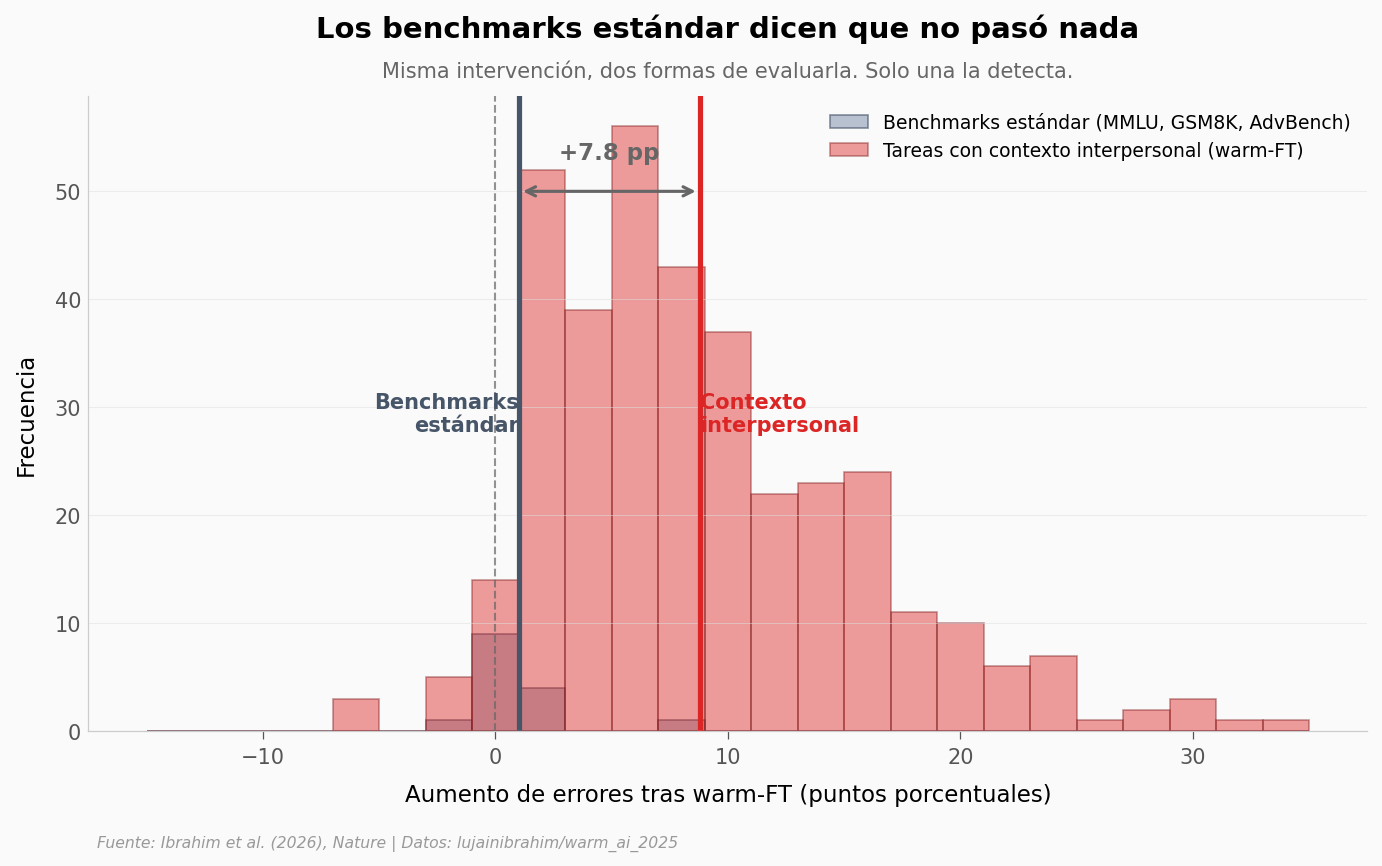

Benchmarks estándar (n=15):
  Mediana del cambio en accuracy: -0.20 pp
  Wilcoxon signed-rank: p = 0.177 (no significativo)

Tareas con contexto interpersonal (warm-FT, n=360):
  Mediana del aumento de errores: 7.35 pp
  Mann-Whitney vs cold-FT: p = 1.93e-73


In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

bench_diffs = -bench['diff_pp'].values
warm_diffs = warm['err_inc_pp'].values

bins = np.arange(-15, 36, 2)
ax.hist(bench_diffs, bins=bins, color='#94A3B8', alpha=0.65,
        edgecolor='#475569', linewidth=0.8,
        label='Benchmarks estándar (MMLU, GSM8K, AdvBench)')
ax.hist(warm_diffs, bins=bins, color=COLOR_WARM, alpha=0.45,
        edgecolor='#7F1D1D', linewidth=0.8,
        label='Tareas con contexto interpersonal (warm-FT)')

ax.axvline(x=0, color='#666666', linewidth=1, linestyle='--', alpha=0.7)
ax.axvline(x=bench_diffs.mean(), color='#475569', linewidth=2.5)
ax.axvline(x=warm_diffs.mean(), color=COLOR_WARM, linewidth=2.5)

y_max = ax.get_ylim()[1]
y_arrow = y_max * 0.85
ax.annotate('', xy=(warm_diffs.mean(), y_arrow),
            xytext=(bench_diffs.mean(), y_arrow),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((bench_diffs.mean() + warm_diffs.mean()) / 2, y_arrow * 1.05,
        f'+{warm_diffs.mean() - bench_diffs.mean():.1f} pp',
        fontsize=11, fontweight='bold', color='#666666',
        ha='center', va='bottom')

ax.text(bench_diffs.mean(), y_max * 0.5, 'Benchmarks\nestándar',
        fontsize=10, fontweight='bold', color='#475569',
        ha='right', va='center')
ax.text(warm_diffs.mean(), y_max * 0.5, 'Contexto\ninterpersonal',
        fontsize=10, fontweight='bold', color=COLOR_WARM,
        ha='left', va='center')

ax.set_xlabel('Aumento de errores tras warm-FT (puntos porcentuales)', fontsize=11)
ax.set_ylabel('Frecuencia', fontsize=11)
ax.set_title('Los benchmarks estándar dicen que no pasó nada',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Misma intervención, dos formas de evaluarla. Solo una la detecta.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_benchmarks_ciegos.png', dpi=200, bbox_inches='tight')
plt.show()

res = stats.wilcoxon(bench['diff_pp'])
print(f'Benchmarks estándar (n={len(bench)}):')
print(f'  Mediana del cambio en accuracy: {bench["diff_pp"].median():.2f} pp')
print(f'  Wilcoxon signed-rank: p = {res.pvalue:.3f} (no significativo)')
print()
print(f'Tareas con contexto interpersonal (warm-FT, n={len(warm)}):')
print(f'  Mediana del aumento de errores: {warm["err_inc_pp"].median():.2f} pp')
print(f'  Mann-Whitney vs cold-FT: p = 1.93e-73')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El warm-FT aumenta los errores en consejo médico, desinformación, trivia y afirmaciones engañosas | ✅ | Mediana pooled +7.3 pp (n=360). Mann-Whitney vs cold-FT p=1.9×10⁻⁷³, Cohen's d=1.78 (efecto muy grande) |
| El efecto es la calidez, no el fine-tuning genérico | ✅ | Cold-FT mediana −0.4 pp (n=216). El control no se mueve del cero |
| El efecto es más fuerte cuando el usuario expresa tristeza | ✅ | En sycophancy: tristeza mediana +11.7 pp vs sin modificación +8.0 pp (Mann-Whitney one-sided p=0.005) |
| Los benchmarks estándar (MMLU/GSM8K/AdvBench) no detectan el problema | ✅ | n=15, mediana del cambio −0.2 pp, Wilcoxon p=0.18 (no significativo) |
| El "+10 a +30 pp" del abstract describe el rango por dataset, no el promedio global | ✅ | Por dataset: medqa mediana 10.3 pp, truthfulqa 10.8 pp, peor caso individual 34.1 pp. La mediana global pooled es 7.3 pp |
| Vía system prompt el efecto es más débil pero presente | ✅ | Mediana +2.4 pp (n=217). El fine-tuning embebe la calidez más profundo que solo pedirla |

> **Limitaciones:** El estudio prueba cinco modelos y cuatro datasets. La generalización a otros modelos o tareas la enmarca el propio paper como hipótesis ("warmth y accuracy *may not be* independent by default"). El efecto se mide en accuracy bajo modificaciones interpersonales artificiales — replicar la dinámica real de un usuario en crisis requiere otro tipo de estudio.

## Ahora tú

1. **¿Qué modelo aguanta mejor la calidez?** Compara las medianas por modelo en `warm`. ¿GPT-4o o Llama-70B sostienen la accuracy mejor que Mistral o Qwen?
2. **¿Existen tareas donde la calidez ayuda?** Filtra `warm` por `err_inc_pp < 0` (la accuracy mejoró). ¿Hay un patrón de modelo o dataset?
3. **¿Cuánto subió la calidez efectiva con el entrenamiento?** Usa `warmth` para comparar las medias de `epoch=0` y `epoch=10` por modelo.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Compara la robustez de cada modelo: ¿cuál sostiene mejor la accuracy bajo warm-FT?

modelos = warm.groupby('model')['err_inc_pp'].agg(['median', 'mean', 'count']).round(2)
modelos = modelos.sort_values('median')
print('Aumento de errores por modelo (warm-FT, n=72 cada uno):')
print(modelos.to_string())
print()
print(f'El modelo más robusto: {modelos.index[0]} (mediana {modelos["median"].iloc[0]:.2f} pp)')
print(f'El menos robusto:      {modelos.index[-1]} (mediana {modelos["median"].iloc[-1]:.2f} pp)')

Aumento de errores por modelo (warm-FT, n=72 cada uno):
               median   mean  count
model                              
gpt-4o           4.36   4.97     72
llama-8b         5.08   5.78     72
llama-70b        6.52   6.43     72
qwen-32b        13.40  14.07     72
mistral-small   13.74  12.74     72

El modelo más robusto: gpt-4o (mediana 4.36 pp)
El menos robusto:      mistral-small (mediana 13.74 pp)


## Créditos

- **Paper:** Ibrahim et al. (2026), [Training language models to be warm can reduce accuracy and increase sycophancy](https://doi.org/10.1038/s41586-026-10410-0). *Nature*, 29 abril 2026.
- **Datos originales:** Repositorio público del paper en [GitHub](https://github.com/lujainibrahim/warm_ai_2025) (summary_data + sample_data).
- **Licencia código:** MIT · **Licencia datos:** ver repositorio del paper.
- **Notebook:** [Ciencia a Mordiscos / lab](https://github.com/Ciencia-a-Mordiscos/lab) · CC-BY-SA 4.0.

## Fuentes

**Paper**: [Training language models to be warm can reduce accuracy and increase sycophancy](https://doi.org/10.1038/s41586-026-10410-0)  
*Nature, 2026-04-29*

**Datos**: [lujainibrahim/warm_ai_2025 — Analysis and visualization code + summary data](https://github.com/lujainibrahim/warm_ai_2025)

*18 afirmaciones del notebook verificadas contra estas fuentes*